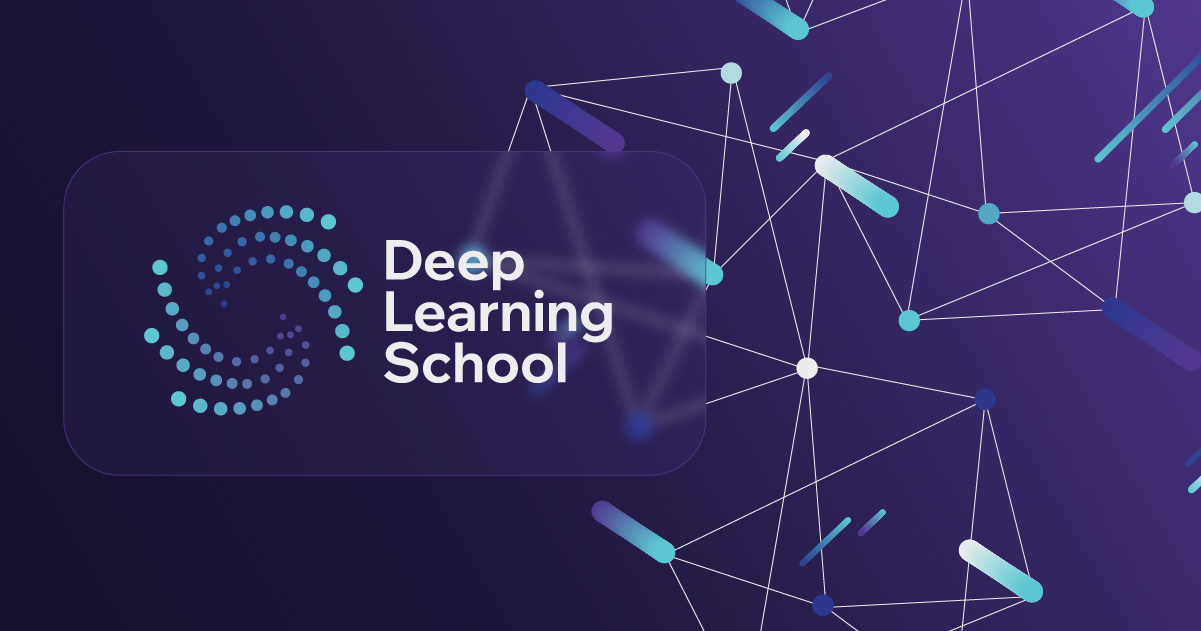

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Решение конкурса на kaggle</b></h1>

Импорт библиотек и загрузка данных


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score

In [3]:
!gdown 1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K  # train.csv
!gdown 1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r  # test.csv
!gdown 199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y  # submission.csv

Downloading...
From: https://drive.google.com/uc?id=1ERwQ5odiK1Zvi1LtjpkzCMUswYsAX8_K
To: /content/train.csv
100% 664k/664k [00:00<00:00, 75.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1fGw_-RFwvn_LEdt91Jq-7A-wzG6mmH8r
To: /content/test.csv
100% 218k/218k [00:00<00:00, 76.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=199Mt4OYZNaelT83U-HGDsEYs2YcUGQ6y
To: /content/submission.csv
100% 14.7k/14.7k [00:00<00:00, 39.9MB/s]


In [4]:
data = pd.read_csv('./train.csv')
data_test = pd.read_csv('./test.csv')

Разбиение признаков на числовые и категориальные

In [5]:


num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]


cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

In [6]:
#Nan-ы
data.isna().sum()

,0
ClientPeriod,0
MonthlySpending,0
TotalSpent,0
Sex,0
IsSeniorCitizen,0
HasPartner,0
HasChild,0
HasPhoneService,0
HasMultiplePhoneNumbers,0
HasInternetService,0


Предварительный анализ данных

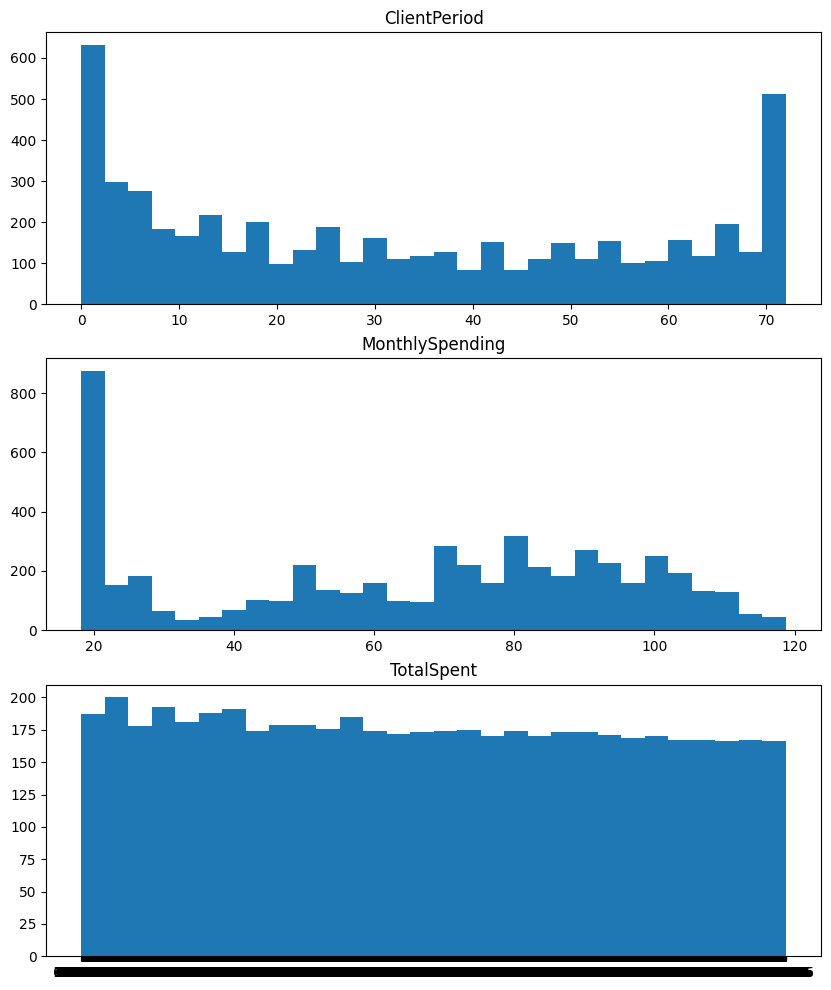

In [7]:
#Распределение численных признаков
fig, axes = plt.subplots(nrows = len(num_cols), ncols = 1, figsize = (10, 4*len(num_cols)))
for ax, col in zip(axes, num_cols):
  ax.hist(data[col], bins = 30)
  ax.set_title(col)

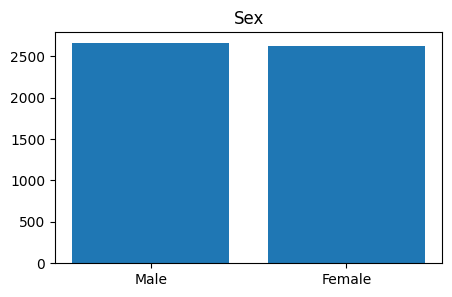

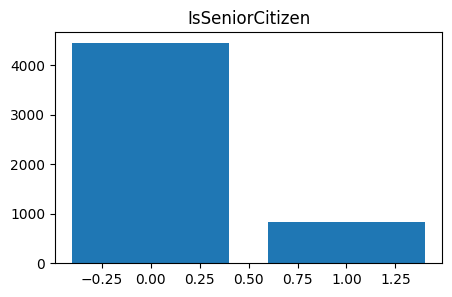

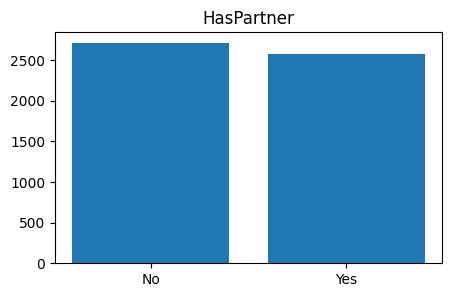

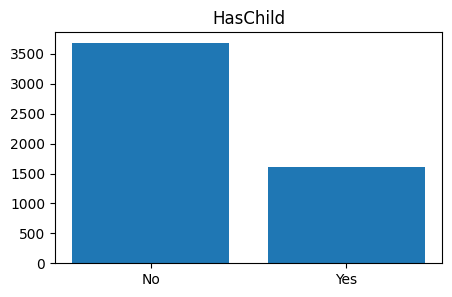

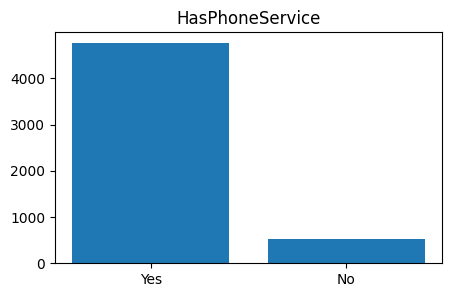

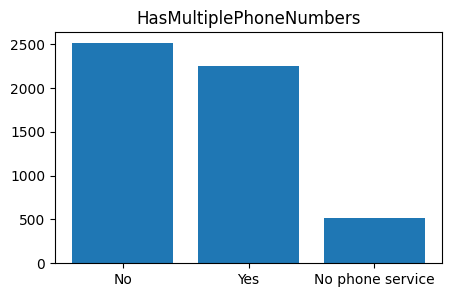

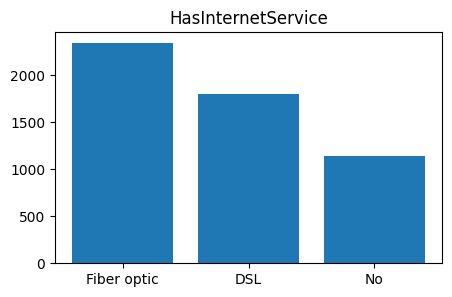

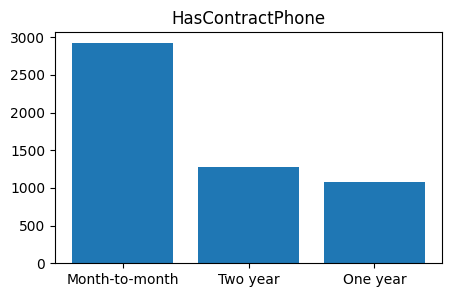

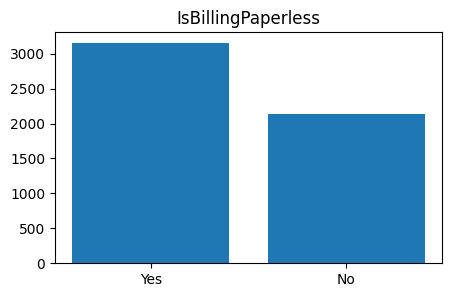

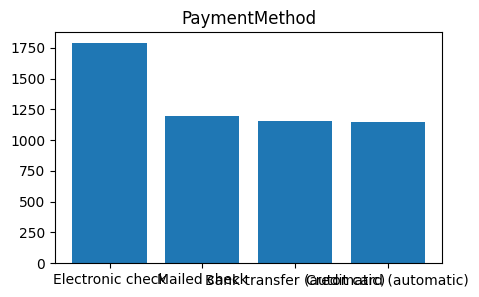

In [8]:
#распределение категориальных признаков
for cat in cat_cols:
  plt.figure(figsize=(5, 3))
  count = data[cat].value_counts()
  plt.bar(count.index, count.values)
  plt.title(f'{cat}')

Text(0.5, 1.0, 'Распределение целевой переменной')

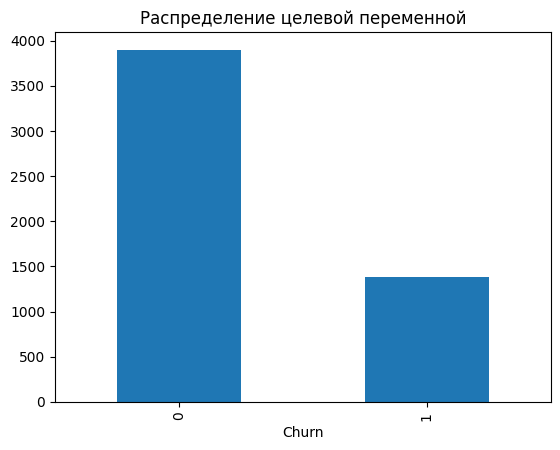

In [9]:
#распределение таргета
data[target_col].value_counts().plot(kind = 'bar')
plt.title('Распределение целевой переменной')
#Очевидно, классы являются несбалансированными, доминирует класс "0"

In [10]:
#признаки HasInternetService, HasOnlineSecurityService', 'HasOnlineBackup','HasDeviceProtection', 'HasMovieSubscription' сильно скоррелированны с HasInternetService,
#при этом наличие интернета, очевидно, более важный признак, поэтому следует оставить только его
data = data.drop(columns=['HasOnlineSecurityService', 'HasOnlineBackup','HasTechSupportAccess','HasOnlineTV',
                          'HasDeviceProtection', 'HasMovieSubscription'])

In [11]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV,  KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

In [12]:
#обработка пропусков в Total_Spent
data['TotalSpent'] = pd.to_numeric(data['TotalSpent'], errors = 'coerce')
data['TotalSpent'] = data['TotalSpent'].fillna(0)
num_pipe = Pipeline([('scaler', RobustScaler())])
cat_pipe = Pipeline([('one_hot', OneHotEncoder())])
preprocessor = ColumnTransformer(transformers = [('num_branch', num_pipe, num_cols), ('cat_branch', cat_pipe, cat_cols)])
log_reg_cv = LogisticRegressionCV(Cs = 10, cv = 5, scoring = 'roc_auc', class_weight = 'balanced', max_iter = 1000, random_state = 42, n_jobs = -1)
pipeline = Pipeline(steps = [('preprocessor', preprocessor), ('classifier', log_reg_cv)])


In [13]:
#кросс - валидация
X_train = data.drop('Churn', axis = 1)
y_train = data['Churn']
pipeline.fit(X_train,  y_train)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv = 5, scoring = 'roc_auc')
print(f"Средний ROC-AUC на кросс-валидации: {cv_scores.mean():.4f}")

Средний ROC-AUC на кросс-валидации: 0.8400


Применение градиентого бустинга

In [14]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [15]:
#CatBoost вместе с GridSearch
from catboost import CatBoostClassifier
data2 =  pd.read_csv('./train.csv')
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]
cb_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    cat_features=cat_cols,
    random_seed=42,
    verbose=False
)
data['TotalSpent'] = pd.to_numeric(data['TotalSpent'], errors='coerce').fillna(0)
X = data2.drop('Churn', axis=1)
y = data2['Churn']
grid_search_result = cb_model.grid_search({'iterations' : [500,1000], 'learning_rate' : [0.01, 0.03, 0.05], 'depth' : [4,6], 'l2_leaf_reg' : [1,3,5]}, X = X, y = y, cv = 3)
print(grid_search_result['params'])


bestTest = 0.8722152165
bestIteration = 446

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
0:	loss: 0.8722152	best: 0.8722152 (0)	total: 14.1s	remaining: 8m 14s

bestTest = 0.8732899614
bestIteration = 116

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
1:	loss: 0.8732900	best: 0.8732900 (1)	total: 28.1s	remaining: 7m 58s

bestTest = 0.8735479002
bestIteration = 192

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
2:	loss: 0.8735479	best: 0.8735479 (2)	total: 33.6s	remaining: 6m 9s

bestTest = 0.8728934999
bestIteration = 358

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
3:	loss: 0.8728935	best: 0.8735479 (2)	total: 39.9s	remaining: 5m 19s



после градиентного бустинга на решающих деревьях с параметрами {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 500} удалось получить (ожидаемое)
качество (ROC AUC) примерно в 0.847, хотя в итерациях были и значения в 0.873

Выгрузка предсказаний

In [16]:
best_model = cb_model

In [17]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')
X_test['TotalSpent'] = pd.to_numeric(X_test['TotalSpent'], errors='coerce').fillna(0)
submission['Churn'] = best_model.predict_proba(X_test)[:, 1]
submission.to_csv('./my_submission.csv')

Итоговая модель достигла значения метрики ROC-AUC = 0.849 на тестовой выборке. Данный результат соответствует максимальному баллу в рамках проверочной системы курса.